In [1]:
netlist = """\
RC Low Pass Filter
Vin in 0 AC $VIN
R1 in out $R
C1 out 0 $C

.AC DEC 100 $FSTART $FSTOP
.SAVE $SAVE_VARS
.END
"""

with open('rc_lpf_orig.cir', 'w') as f:
    f.write(netlist)

In [2]:
import ngspice_calc as calc
import numpy as np
import matplotlib.pyplot as plt

f_start = 10
f_stop = 1e6

s_Vin = 1
s_R = '1k'
s_C = '1u'
l = [
    ('$VIN', f'{s_Vin}'),
    ('$R', s_R),
    ('$C', s_C),
    ('$FSTART', f'{f_start}'),
    ('$FSTOP', f'{f_stop}'),
    ('$SAVE_VARS', 'v(out)')
]

calc.replace_strings_1('rc_lpf_orig.cir', 'rc_lpf.cir', l)
print('rc_lpf.cir ready')

rc_lpf.cir ready


In [3]:
calc.run_ngspice('rc_lpf.cir')


Note: No compatibility mode selected!


Circuit: rc low pass filter

binary raw file "rc_lpf.raw"
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

Using SPARSE 1.3 as Direct Linear Solver
No. of Data Columns : 2  

No. of Data Rows : 501

Total analysis time (seconds) = 0.00115203

Total elapsed time (seconds) = 0.005 

Total DRAM available = 15614.742 MB.
DRAM currently available = 2721.723 MB.
Maximum ngspice program size =   21.406 MB.
Current ngspice program size =   12.609 MB.

Shared ngspice pages =   10.832 MB.
Text (code) pages =    7.105 MB.
Stack = 0 bytes.
Library pages =    1.879 MB.




'rc_lpf.raw'

In [4]:
s = calc.slv('rc_lpf.cir')

print("Number of plots: ", s.num_plots())
for i in range(s.num_plots()):
    print(f"plot {i}: {s.plotname(i)} | type: {s.analysis_type()} | vars: {s.variables()}")

Number of plots:  1
plot 0: AC Analysis | type: tran | vars: ['frequency', 'v(out)']


In [5]:
freq = s.get_array('frequency')
v_out = s.get_array('v(out)')

mag_db = calc.to_db(v_out, s_Vin)
phase_deg = calc.to_degree(v_out, s_Vin)

f_3db = 1 / (2 * np.pi * 1e3 * 1e-6)

v_at_f3db     = calc.interp_at(freq, mag_db, f_3db)
phase_at_f3db = calc.interp_at(freq, phase_deg, f_3db)

print(f"At f_3db = {f_3db:.2f} Hz:")
print(f"phase = {phase_at_f3db:.4f} deg (expected -45.0000 deg)")


mag = np.abs(v_out).real
v_at_f3db = calc.interp_at(freq, mag, f_3db)
print(f"|V(out)| = {v_at_f3db:.6f} V (expected {1/np.sqrt(2):.6f} V)")

At f_3db = 159.15 Hz:
phase = -44.9989 deg (expected -45.0000 deg)
|V(out)| = 0.707114 V (expected 0.707107 V)


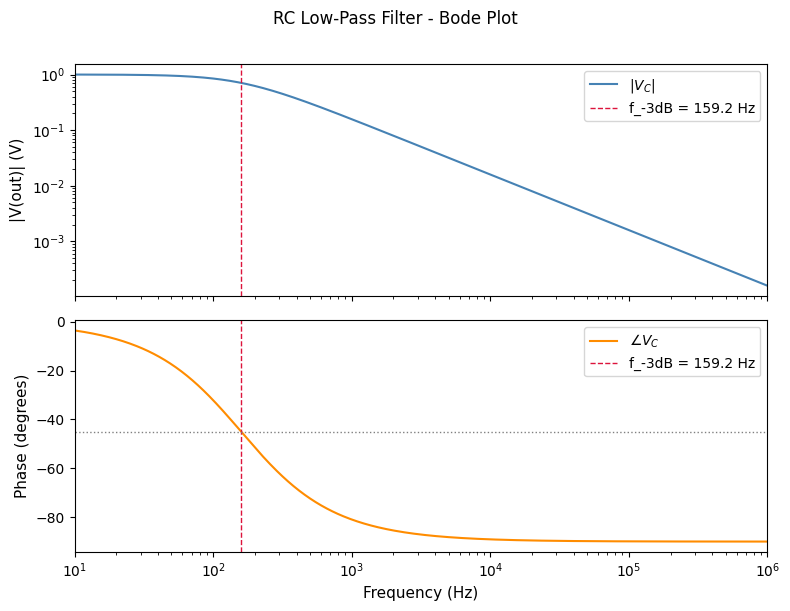

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,6), sharex=True)
plt.subplots_adjust(hspace=0.08)

for ax in (ax1, ax2):
    # ax.grid(which='both', color='#CCCCCC', linestyle='solid', linewidth=0.5)
    ax.set_xlim(freq[0], freq[-1])

# Plot 1 - magnitude log-log
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.plot(freq, np.abs(v_out), color='steelblue', linewidth=1.5, label=r'$|V_C|$')
ax1.axvline(f_3db, color='crimson', linestyle='--', linewidth=1.0, label=f'f_-3dB = {f_3db:.1f} Hz')
ax1.set_ylabel('|V(out)| (V)', fontsize=11)
ax1.legend(fontsize=10)
ax1.tick_params(labelbottom=False)

# Plot 2 - phase, x log scale, y linear
ax2.set_xscale('log')
ax2.plot(freq, phase_deg, color='darkorange', linewidth=1.5, label=r'$\angle V_C$')
ax2.axvline(f_3db, color='crimson', linestyle='--', linewidth=1.0, label=f'f_-3dB = {f_3db:.1f} Hz')
ax2.axhline(-45, color='gray', linestyle=':', linewidth=1.0)
ax2.set_ylabel('Phase (degrees)', fontsize=11)
ax2.set_xlabel('Frequency (Hz)', fontsize=11)
ax2.legend(fontsize=10)

plt.suptitle('RC Low-Pass Filter - Bode Plot', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

|V(out)| = 0.707114 V  (expected 0.707107 V)
